# Niamey station fitting
<!-- markdownlint-disable MD013 -->
Using GRDC data, compared to ABN data. Define curve fit between discharge and stage

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [120]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

from src.datasources import grdc, abn
from src.utils.rating_curve import calculate_stage
from src.constants import *

In [10]:
df_abn = abn.load_abn_niamey(local=True)

In [11]:
df_abn

,Water Level (cm),Discharges (m3/s)
Date,,
2005-01-01,459.667,1367.244
2005-01-02,457.667,1354.711
2005-01-03,455.667,1342.178
2005-01-04,453.667,1329.644
2005-01-05,451.000,1312.933
...,...,...
2022-07-28,298.000,355.000
2022-07-29,298.000,355.000
2022-07-30,336.000,485.500


In [7]:
df_grdc = grdc.load_grdc(station_id=NIAMEY_GRDC_ID)

In [12]:
df_grdc

,time,runoff_mean
0,1929-01-01,1691.160034
1,1929-01-02,NaN
2,1929-01-03,NaN
3,1929-01-04,NaN
4,1929-01-05,NaN
...,...,...
35227,2025-06-13,119.000000
35228,2025-06-14,115.000000
35229,2025-06-15,134.000000
35230,2025-06-16,165.000000


In [14]:
df_compare = (
    df_abn.reset_index().rename(columns={"Date": "time"}).merge(df_grdc)
)

In [16]:
df_compare.corr()

,time,Water Level (cm),Discharges (m3/s),runoff_mean
time,1.000000,0.145618,0.042346,0.042260
Water Level (cm),0.145618,1.000000,0.978188,0.978177
Discharges (m3/s),0.042346,0.978188,1.000000,0.999998
runoff_mean,0.042260,0.978177,0.999998,1.000000


In [26]:
recent_x, recent_y = 508, 1311

In [32]:
df_compare

,time,Water Level (cm),Discharges (m3/s),runoff_mean
0,2005-01-01,459.667,1367.244,1367.244019
1,2005-01-02,457.667,1354.711,1354.711060
2,2005-01-03,455.667,1342.178,1342.177979
3,2005-01-04,453.667,1329.644,1329.644043
4,2005-01-05,451.000,1312.933,1312.932983
...,...,...,...,...
6417,2022-07-28,298.000,355.000,355.000000
6418,2022-07-29,298.000,355.000,355.000000
6419,2022-07-30,336.000,485.500,485.666992
6420,2022-07-31,361.500,585.500,585.666992


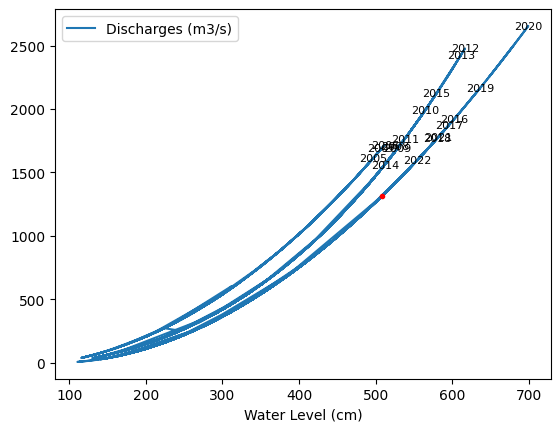

In [31]:
xcol, ycol = "Water Level (cm)", "Discharges (m3/s)"

fig, ax = plt.subplots()
df_compare.plot(x=xcol, y=ycol, ax=ax)
for year, row in (
    df_compare.groupby(df_compare["time"].dt.year)[[xcol, ycol]]
    .max()
    .iterrows()
):
    ax.annotate(year, row[[xcol, ycol]], ha="center", va="center", fontsize=8)

ax.plot([recent_x], [recent_y], marker=".", color="red")

Looks like the update the discharge-level curve every few years. But based on the recent point (from 2025), they are still using that most recent curve (from 2016 to 2022), so we can use that one.

In [76]:
def fit_rating_curve_loglog(
    df, stage_col="stage", discharge_col="discharge", h0=None
):
    # Drop NaNs and non-positive discharge
    df = df[[stage_col, discharge_col]].dropna()
    df = df[df[discharge_col] > 0]

    h = df[stage_col].values
    Q = df[discharge_col].values

    if h0 is None:
        h0 = np.min(h)  # You can tweak this manually

    h_adj = h - h0
    mask = h_adj > 0
    h_adj = h_adj[mask]
    Q = Q[mask]

    log_h = np.log(h_adj)
    log_Q = np.log(Q)

    slope, intercept, _, _, _ = linregress(log_h, log_Q)
    b = slope
    a = np.exp(intercept)

    return a, b, h0

In [77]:
df_curve_fit = df_compare[df_compare["time"].dt.year >= 2017].copy()

<Axes: xlabel='Water Level (cm)'>

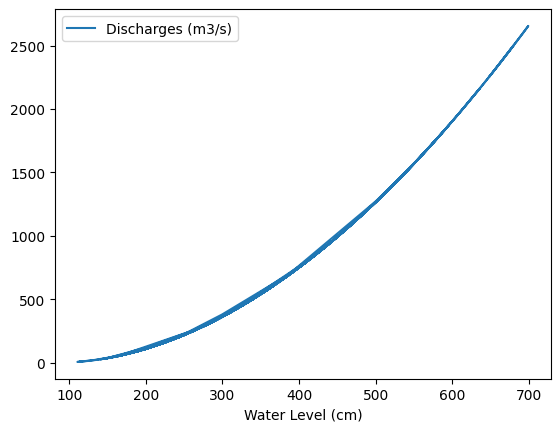

In [78]:
df_curve_fit.plot(x=xcol, y=ycol)

In [79]:
df_curve_fit = df_curve_fit.sort_values("Water Level (cm)")

<Axes: xlabel='Water Level (cm)'>

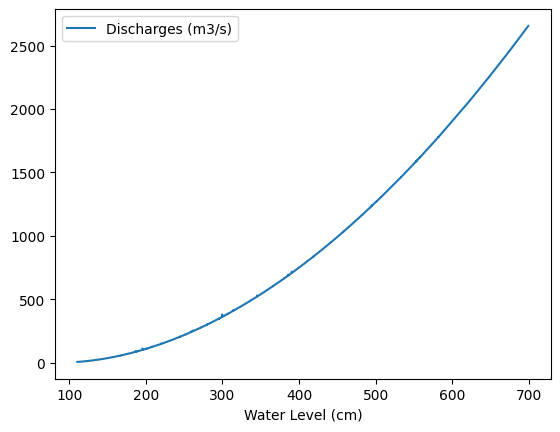

In [80]:
df_curve_fit.plot(x=xcol, y=ycol)

In [84]:
a, b, h0 = fit_rating_curve_loglog(
    df_curve_fit,
    stage_col="Water Level (cm)",
    discharge_col="Discharges (m3/s)",
)
print(f"Fitted parameters:\na = {a:.4f}, b = {b:.4f}, h0 = {h0:.4f}")

Fitted parameters:
a = 0.1651, b = 1.4883, h0 = 110.6670


In [90]:
def predict_discharge(stage, a, b, h0):
    stage = np.array(stage)
    stage_adj = np.maximum(stage - h0, 1e-6)
    return a * stage_adj**b

In [91]:
df_curve_fit["pred_dis"] = predict_discharge(
    df_curve_fit["Water Level (cm)"], a, b, h0
)

In [92]:
df_curve_fit["pred_dis"] = predict_discharge(
    df_curve_fit["Water Level (cm)"], a, b, h0
)

<Axes: xlabel='Water Level (cm)'>

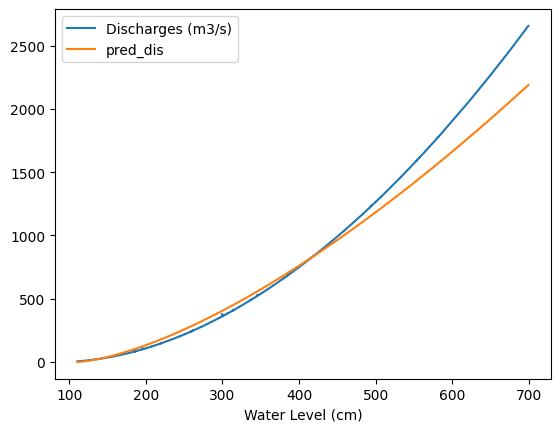

In [93]:
fig, ax = plt.subplots()
df_curve_fit.plot(x="Water Level (cm)", y="Discharges (m3/s)", ax=ax)
df_curve_fit.plot(x="Water Level (cm)", y="pred_dis", ax=ax)

Ok after various tweaks to the standard fitting it doesn't really look that good. We can try 

In [98]:
def fit_polynomial_rating_curve(
    df,
    stage_col="Water Level (cm)",
    discharge_col="Discharges (m3/s)",
    degree=2,
):
    df = df[[stage_col, discharge_col]].dropna()

    x = df[stage_col].values
    y = df[discharge_col].values

    coeffs = np.polyfit(x, y, deg=degree)
    poly = np.poly1d(coeffs)

    return poly  # This is a callable function

In [110]:
poly = fit_polynomial_rating_curve(df_curve_fit, degree=2)
df_curve_fit["Q_pred"] = poly(df_curve_fit["Water Level (cm)"])

In [111]:
poly

poly1d([ 6.46864019e-03, -6.84291035e-01, -1.22030009e+01])

<Axes: xlabel='Water Level (cm)'>

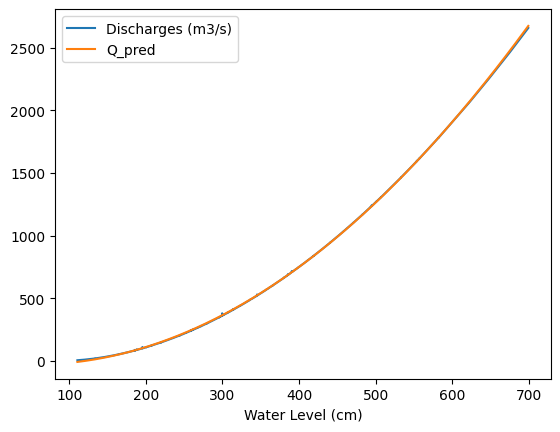

In [112]:
fig, ax = plt.subplots()
df_curve_fit.plot(x="Water Level (cm)", y="Discharges (m3/s)", ax=ax)
df_curve_fit.plot(x="Water Level (cm)", y="Q_pred", ax=ax)

In [115]:
def invert_quadratic(Q, poly, root="max"):
    """
    Invert a quadratic polynomial to get stage from discharge.

    Parameters:
    - Q: scalar or array of discharge values
    - poly: a degree-2 numpy.poly1d object
    - root: 'max' (default) or 'min' to choose which root to return

    Returns:
    - h: estimated stage(s)
    """
    Q = np.atleast_1d(Q)
    a, b, c = poly.coefficients  # poly1d stores in descending order

    h_values = []
    for q in Q:
        discriminant = b**2 - 4 * a * (c - q)
        if discriminant < 0:
            h_values.append(np.nan)
        else:
            sqrt_d = np.sqrt(discriminant)
            h1 = (-b + sqrt_d) / (2 * a)
            h2 = (-b - sqrt_d) / (2 * a)
            h_values.append(max(h1, h2) if root == "max" else min(h1, h2))

    return np.array(h_values) if len(h_values) > 1 else h_values[0]

In [117]:
df_curve_fit["stage_pred"] = invert_quadratic(
    df_curve_fit["Discharges (m3/s)"], poly
)

<Axes: xlabel='Water Level (cm)'>

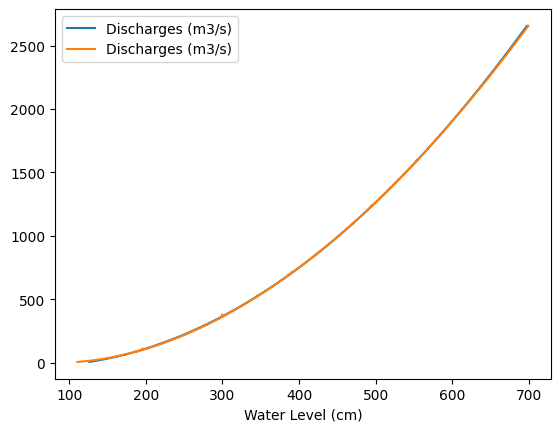

In [125]:
fig, ax = plt.subplots()
df_curve_fit.plot(x="stage_pred", y="Discharges (m3/s)", ax=ax)
df_curve_fit.plot(x="Water Level (cm)", y="Discharges (m3/s)", ax=ax)

In [122]:
df_curve_fit["stage_pred_func"] = calculate_stage(
    df_curve_fit["Discharges (m3/s)"]
)

<Axes: xlabel='Water Level (cm)'>

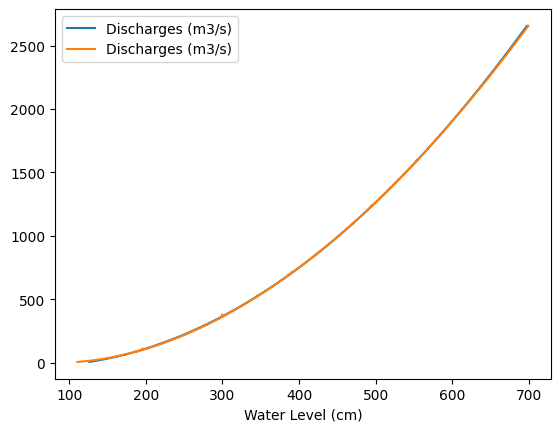

In [124]:
fig, ax = plt.subplots()
df_curve_fit.plot(x="stage_pred_func", y="Discharges (m3/s)", ax=ax)
df_curve_fit.plot(x="Water Level (cm)", y="Discharges (m3/s)", ax=ax)